# Sequence Model

|         |                               |
| :------ | :---------------------------- |
| Dataset | Epileptic Seizure Recognition |
| Model   | LSTM                          |

In [1]:
# ============================================================
# BLOK 1 - IMPORT LIBRARY
# ============================================================

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")
plt.style.use("ggplot")


2026-04-19 10:41:41.941060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776595302.149745      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776595302.212326      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776595302.696331      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776595302.696378      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776595302.696381      23 computation_placer.cc:177] computation placer alr

## Blok 1

Mengimpor library utama untuk:
- membaca dataset
- preprocessing
- membangun model TensorFlow
- training
- evaluasi
- visualisasi hasil

In [2]:
# ============================================================
# BLOK 2 - KONFIGURASI
# ============================================================

SEED = 42
MODEL_NAME = "LSTM"

VAL_SIZE = 0.15
TEST_SIZE = 0.15

BATCH_SIZE = 64
EPOCHS = 45
LEARNING_RATE = 1e-3

LSTM_UNITS_1 = 192
LSTM_UNITS_2 = 96
LSTM_DROPOUT = 0.00
ATTN_HEADS = 4
ATTN_KEY_DIM = 32
ATTN_DROPOUT = 0.10
DENSE_UNITS = 128
DENSE_DROPOUT = 0.25

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print({
    "MODEL_NAME": MODEL_NAME,
    "VAL_SIZE": VAL_SIZE,
    "TEST_SIZE": TEST_SIZE,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "LSTM_UNITS_1": LSTM_UNITS_1,
    "LSTM_UNITS_2": LSTM_UNITS_2,
    "LSTM_DROPOUT": LSTM_DROPOUT,
    "ATTN_HEADS": ATTN_HEADS,
    "ATTN_KEY_DIM": ATTN_KEY_DIM,
    "ATTN_DROPOUT": ATTN_DROPOUT,
    "DENSE_UNITS": DENSE_UNITS,
    "DENSE_DROPOUT": DENSE_DROPOUT,
})


{'MODEL_NAME': 'LSTM', 'VAL_SIZE': 0.15, 'TEST_SIZE': 0.15, 'BATCH_SIZE': 64, 'EPOCHS': 45, 'LEARNING_RATE': 0.001, 'LSTM_UNITS_1': 192, 'LSTM_UNITS_2': 96, 'LSTM_DROPOUT': 0.0, 'ATTN_HEADS': 4, 'ATTN_KEY_DIM': 32, 'ATTN_DROPOUT': 0.1, 'DENSE_UNITS': 128, 'DENSE_DROPOUT': 0.25}


## Blok 2
Menentukan parameter eksperimen

Konfigurasi model:
- LSTM bertingkat satu arah
- kapasitas layer diperbesar secara moderat
- self-attention pada representasi sequence
- dense layer tetap ringkas
- learning rate dibuat setara dengan model RNN acuan


In [3]:

# ============================================================
# BLOK 3 - MENCARI FILE DATASET DI /kaggle/input
# ============================================================

ROOT_INPUT = Path("/kaggle/input")

def search_candidate_csv():
    if not ROOT_INPUT.exists():
        raise FileNotFoundError("Folder /kaggle/input tidak ditemukan.")

    candidates = []
    for p in ROOT_INPUT.rglob("*.csv"):
        name = p.name.lower()
        if (
            "epileptic" in name
            or "seizure" in name
            or name == "data.csv"
            or name == "epileptic_seizure_data.csv"
        ):
            candidates.append(p)

    if not candidates:
        all_csv = list(ROOT_INPUT.rglob("*.csv"))
        if not all_csv:
            raise FileNotFoundError("Tidak ada file CSV yang ditemukan di /kaggle/input.")
        candidates = all_csv

    candidates = sorted(candidates, key=lambda x: (len(str(x)), str(x)))
    return candidates

candidate_files = search_candidate_csv()
for i, p in enumerate(candidate_files[:20]):
    print(f"[{i}] {p}")

data_path = candidate_files[0]
print("\nFile terpilih:", data_path)

[0] /kaggle/input/datasets/yasserhessein/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv

File terpilih: /kaggle/input/datasets/yasserhessein/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv


## Blok 3

Pencarian file dibuat otomatis di `/kaggle/input` agar tetap fleksibel saat dataset ditambahkan ke notebook. Prioritas diarahkan ke file CSV yang mengandung kata **epileptic** atau **seizure**.

In [4]:

# ============================================================
# BLOK 4 - MEMBACA DATASET
# ============================================================

df = pd.read_csv(data_path)

print("Shape awal:", df.shape)
display(df.head())
print("\nNama kolom:")
print(df.columns.tolist()[:10], "...", df.columns.tolist()[-10:])

Shape awal: (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5



Nama kolom:
['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9'] ... ['X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178', 'y']


## Blok 4

Dataset dibaca dari satu file CSV utama. Pengecekan awal dilakukan untuk melihat bentuk tabel, nama kolom, dan struktur umum data.

In [5]:

# ============================================================
# BLOK 5 - MEMBERSIHKAN STRUKTUR KOLOM
# ============================================================

df = df.copy()

# Hapus kolom indeks tambahan jika ada
first_col = str(df.columns[0]).lower()
if "unnamed" in first_col:
    df = df.drop(columns=df.columns[0])

# Pastikan kolom target ditemukan
target_col = None
for col in df.columns:
    col_lower = str(col).lower()
    if col_lower == "y" or col_lower == "label" or col_lower == "target":
        target_col = col
        break

if target_col is None:
    target_col = df.columns[-1]

feature_cols = [c for c in df.columns if c != target_col]

# Pastikan fitur numerik
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna().reset_index(drop=True)

print("Target column:", target_col)
print("Jumlah fitur :", len(feature_cols))
print("Shape bersih :", df.shape)

Target column: y
Jumlah fitur : 178
Shape bersih : (11500, 179)


## Blok 5

Kolom indeks tambahan dibuang bila ada. Seluruh fitur diubah ke numerik agar rangkaian sinyal dapat diproses langsung sebagai sequence.

In [6]:

# ============================================================
# BLOK 6 - MEMISAHKAN FITUR DAN LABEL
# ============================================================

X = df[feature_cols].to_numpy(dtype="float32")
y = df[target_col].to_numpy()

print("Shape fitur :", X.shape)
print("Shape target:", y.shape)
print("Label unik  :", np.unique(y))

Shape fitur : (11500, 178)
Shape target: (11500,)
Label unik  : [1 2 3 4 5]


## Blok 6

Setiap baris merepresentasikan satu segmen sinyal EEG. Fitur berisi deret nilai sinyal, sedangkan kolom target berisi kelas aktivitas otak.

,label,jumlah_sampel
0,1,2300
1,2,2300
2,3,2300
3,4,2300
4,5,2300


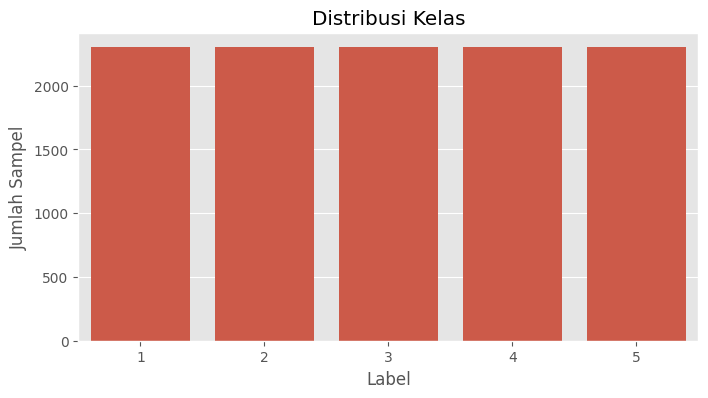

In [7]:

# ============================================================
# BLOK 7 - CEK DISTRIBUSI KELAS
# ============================================================

class_dist = pd.Series(y).value_counts().sort_index()
dist_df = class_dist.reset_index()
dist_df.columns = ["label", "jumlah_sampel"]

display(dist_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=dist_df, x="label", y="jumlah_sampel")
plt.title("Distribusi Kelas")
plt.xlabel("Label")
plt.ylabel("Jumlah Sampel")
plt.show()

## Blok 7

Distribusi kelas dilihat lebih dulu untuk memastikan proporsi data antarkelas. Tahap ini membantu membaca hasil evaluasi sejak awal.

In [8]:

# ============================================================
# BLOK 8 - ENCODE LABEL MENJADI 0 SAMPAI N-1
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_names = [str(c) for c in label_encoder.classes_]
num_classes = len(class_names)

print("Class names :", class_names)
print("Jumlah kelas:", num_classes)

Class names : ['1', '2', '3', '4', '5']
Jumlah kelas: 5


## Blok 8

Label diubah ke format numerik berurutan agar sesuai untuk `SparseCategoricalCrossentropy`. Indeks target menjadi lebih rapi tanpa mengubah urutan kelas asli.

In [9]:

# ============================================================
# BLOK 9 - TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_encoded
)

val_ratio_adjusted = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_ratio_adjusted,
    random_state=SEED,
    stratify=y_trainval
)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape  :", X_val.shape, y_val.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (8050, 178) (8050,)
Val shape  : (1725, 178) (1725,)
Test shape : (1725, 178) (1725,)


## Blok 9

Data dibagi menjadi train, validation, dan test dengan **stratify** agar proporsi kelas tetap terjaga pada setiap subset.

In [10]:

# ============================================================
# BLOK 10 - NORMALISASI PER SAMPEL
# ============================================================

def rowwise_zscore(arr):
    arr = arr.astype("float32")
    mean = arr.mean(axis=1, keepdims=True)
    std = arr.std(axis=1, keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)
    out = (arr - mean) / std
    out = np.clip(out, -5.0, 5.0)
    return out.astype("float32")

X_train_norm = rowwise_zscore(X_train)
X_val_norm   = rowwise_zscore(X_val)
X_test_norm  = rowwise_zscore(X_test)

print("Shape train normalized:", X_train_norm.shape)
print("Contoh mean/std train sample:",
      round(float(X_train_norm[0].mean()), 4),
      round(float(X_train_norm[0].std()), 4))

Shape train normalized: (8050, 178)
Contoh mean/std train sample: 0.0 1.0


## Blok 10

Normalisasi dilakukan **per sampel** agar pola bentuk gelombang tiap segmen lebih menonjol dibandingkan perbedaan skala absolut antarsegmen.

In [11]:

# ============================================================
# BLOK 11 - BENTUK ULANG MENJADI TENSOR SEQUENCE
# ============================================================

sequence_length = X_train_norm.shape[1]

X_train_seq = X_train_norm.reshape(-1, sequence_length, 1)
X_val_seq   = X_val_norm.reshape(-1, sequence_length, 1)
X_test_seq  = X_test_norm.reshape(-1, sequence_length, 1)

y_train_np = np.asarray(y_train).astype("int32")
y_val_np   = np.asarray(y_val).astype("int32")
y_test_np  = np.asarray(y_test).astype("int32")

print("Train sequence shape:", X_train_seq.shape)
print("Val sequence shape  :", X_val_seq.shape)
print("Test sequence shape :", X_test_seq.shape)

Train sequence shape: (8050, 178, 1)
Val sequence shape  : (1725, 178, 1)
Test sequence shape : (1725, 178, 1)


## Blok 11

Model LSTM menerima input berbentuk `(jumlah_sampel, panjang_sequence, fitur_per_timestep)`. Karena setiap timestep hanya memuat satu nilai sinyal, dimensi terakhir bernilai 1.

In [12]:

# ============================================================
# BLOK 12 - MEMBUAT TF.DATA PIPELINE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_np))
    .shuffle(buffer_size=min(len(X_train_seq), 4096), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_np))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_np))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

I0000 00:00:1776595328.395928      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776595328.401677      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## Blok 12

Pipeline `tf.data` dipakai agar aliran data saat training lebih efisien dan format input tetap konsisten sampai evaluasi.

In [13]:
# ============================================================
# BLOK 13 - MEMBANGUN ARSITEKTUR LSTM
# ============================================================

inputs = layers.Input(shape=(sequence_length, 1), name="input_sequence")

x = layers.LSTM(
    LSTM_UNITS_1,
    activation="tanh",
    return_sequences=True,
    dropout=LSTM_DROPOUT,
    recurrent_dropout=0.0,
    name="lstm_1"
)(inputs)

x = layers.LSTM(
    LSTM_UNITS_2,
    activation="tanh",
    return_sequences=True,
    dropout=LSTM_DROPOUT,
    recurrent_dropout=0.0,
    name="lstm_2"
)(x)

attn = layers.MultiHeadAttention(
    num_heads=ATTN_HEADS,
    key_dim=ATTN_KEY_DIM,
    dropout=ATTN_DROPOUT,
    name="self_attention"
)(x, x)

x = layers.Add(name="residual_add")([x, attn])
x = layers.LayerNormalization(name="post_attn_norm")(x)

x_avg = layers.GlobalAveragePooling1D(name="gap")(x)
x_max = layers.GlobalMaxPooling1D(name="gmp")(x)
x = layers.Concatenate(name="merge_pool")([x_avg, x_max])

x = layers.Dense(DENSE_UNITS, activation="relu", name="dense_1")(x)
x = layers.Dropout(DENSE_DROPOUT, name="dropout_dense")(x)

outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

model = models.Model(inputs=inputs, outputs=outputs, name="epileptic_lstm")

optimizer = optimizers.Adam(
    learning_rate=LEARNING_RATE,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "epileptic_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 178, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 178, 192)  │    148,992 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 178, 96)   │    110,976 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 178, 96)   │     49,632 │ lstm_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_add (Add)  │ (None, 178, 96)   │          0 │ lstm_2[0][0],     │
│                     │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_attn_norm      │ (None, 178, 96)   │        192 │ residual_add[0][… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 96)        │          0 │ post_attn_norm[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp                 │ (None, 96)        │          0 │ post_attn_norm[0… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_pool          │ (None, 192)       │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ gmp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     24,704 │ merge_pool[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_dense       │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        645 │ dropout_dense[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 335,141 (1.28 MB)

 Trainable params: 335,141 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

## Blok 13

Arsitektur memakai **LSTM bertingkat satu arah** agar tetap berbeda dari file **BiLSTM**.  
Bagian akhir menggunakan **self-attention**, **global average pooling**, dan **global max pooling** untuk merangkum informasi sequence tanpa bergantung pada satu timestep saja.


In [14]:
# ============================================================
# BLOK 14 - CALLBACK TRAINING
# ============================================================

checkpoint_path = f"best_{MODEL_NAME.lower()}_epileptic_v2.keras"

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True
    )
]


## Blok 14

Callback dipakai untuk menghentikan training saat validation tidak membaik, menurunkan learning rate saat perlu, dan menyimpan bobot terbaik.

In [15]:

# ============================================================
# BLOK 15 - TRAINING MODEL
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/45


I0000 00:00:1776595335.297036      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.3717 - loss: 1.4220 - val_accuracy: 0.4997 - val_loss: 1.0933 - learning_rate: 0.0010
Epoch 2/45
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.5330 - loss: 1.0401 - val_accuracy: 0.6162 - val_loss: 0.8690 - learning_rate: 0.0010
Epoch 3/45
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5746 - loss: 0.9468 - val_accuracy: 0.6441 - val_loss: 0.8036 - learning_rate: 0.0010
Epoch 4/45
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6185 - loss: 0.8470 - val_accuracy: 0.6075 - val_loss: 0.8443 - learning_rate: 0.0010
Epoch 5/45
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6562 - loss: 0.7770 - val_accuracy: 0.6742 - val_loss: 0.7030 - learning_rate: 0.0010
Epoch 6/45
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6613 - loss: 0.7485 - val_accuracy: 0.6951 - val_loss: 0.6852 - learning_rate: 0.0010
Epoch 7/45
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6701 - loss: 0.7127 - val

## Blok 15

Training dilakukan pada data train dan dipantau menggunakan validation set. Riwayat training disimpan untuk melihat perubahan loss dan accuracy antarepoch.

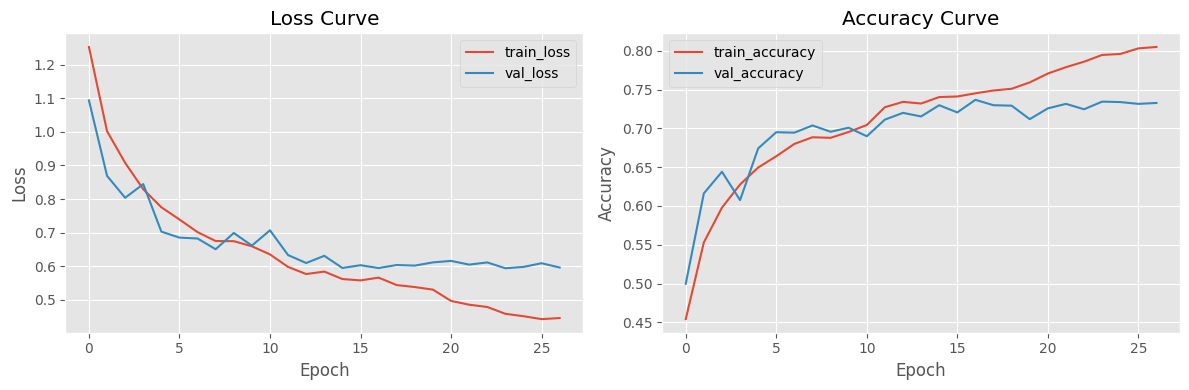

In [16]:

# ============================================================
# BLOK 16 - VISUALISASI LEARNING CURVE
# ============================================================

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Blok 16

Kurva training membantu membaca apakah model mulai stabil, underfitting, atau overfitting.

In [17]:

# ============================================================
# BLOK 17 - PREDIKSI PADA DATA TEST
# ============================================================

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

y_proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

print("Test loss     :", round(float(test_loss), 6))
print("Test accuracy :", round(float(test_accuracy), 6))

Test loss     : 0.566804
Test accuracy : 0.733333


## Blok 17

Prediksi probabilitas pada data test diubah menjadi label akhir dengan `argmax`. Tahap ini menghasilkan output utama yang dipakai pada metrik evaluasi.

In [18]:

# ============================================================
# BLOK 18 - MENGHITUNG METRIK EVALUASI
# ============================================================

metrics_dict = {
    "accuracy": accuracy_score(y_test_np, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test_np, y_pred),
    "precision_macro": precision_score(y_test_np, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test_np, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test_np, y_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_test_np, y_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_test_np, y_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_test_np, y_pred, average="weighted", zero_division=0),
    "roc_auc_ovr_macro": None,
    "roc_auc_ovr_weighted": None,
}

try:
    metrics_dict["roc_auc_ovr_macro"] = roc_auc_score(
        y_test_np, y_proba, multi_class="ovr", average="macro"
    )
    metrics_dict["roc_auc_ovr_weighted"] = roc_auc_score(
        y_test_np, y_proba, multi_class="ovr", average="weighted"
    )
except Exception as e:
    print("ROC-AUC tidak dapat dihitung:", e)

for k, v in metrics_dict.items():
    print(f"{k:22s}: {None if v is None else round(float(v), 6)}")

accuracy              : 0.733333
balanced_accuracy     : 0.733333
precision_macro       : 0.736335
recall_macro          : 0.733333
f1_macro              : 0.731821
precision_weighted    : 0.736335
recall_weighted       : 0.733333
f1_weighted           : 0.731821
roc_auc_ovr_macro     : 0.944499
roc_auc_ovr_weighted  : 0.944499


## Blok 18

Metrik evaluasi.

Metrik utama yang dicatat:
- accuracy
- balanced accuracy
- precision
- recall
- f1-score
- ROC-AUC multiclass
- test loss

In [19]:

# ============================================================
# BLOK 19 - CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test_np,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           1     0.9407    0.9652    0.9528       345
           2     0.6300    0.5971    0.6131       345
           3     0.6142    0.5768    0.5949       345
           4     0.8356    0.7072    0.7661       345
           5     0.6612    0.8203    0.7322       345

    accuracy                         0.7333      1725
   macro avg     0.7363    0.7333    0.7318      1725
weighted avg     0.7363    0.7333    0.7318      1725



## Blok 19

Classification report untuk melihat performa tiap kelas secara detail.

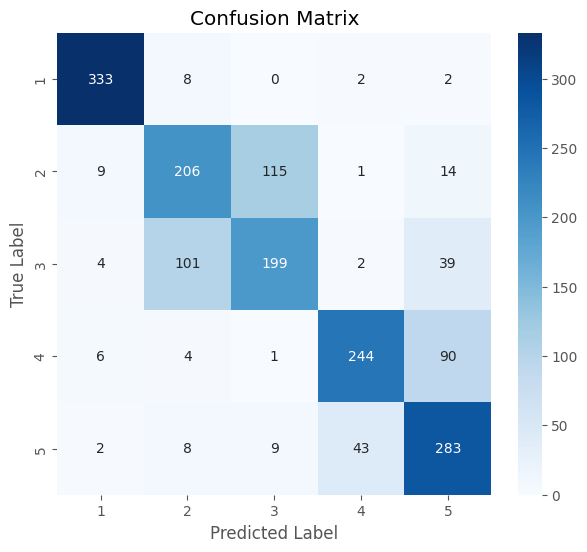

In [20]:

# ============================================================
# BLOK 20 - CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Blok 20

Confusion matrix menunjukkan pola prediksi benar dan salah pada setiap kelas sehingga kelas yang sering tertukar bisa terlihat lebih jelas.

In [21]:

# ============================================================
# BLOK 21 - MENYIMPAN HASIL RINGKAS
# ============================================================

results_path = f"results_{MODEL_NAME.lower()}_epileptic_v2.json"

serializable_results = {
    "model": MODEL_NAME,
    "class_names": class_names,
    "metrics": {
        k: (None if v is None else float(v))
        for k, v in metrics_dict.items()
    },
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy)
}

with open(results_path, "w") as f:
    json.dump(serializable_results, f, indent=2)

print(f"Hasil ringkas disimpan di: {results_path}")

Hasil ringkas disimpan di: results_lstm_epileptic_v2.json


## Blok 21

Hasil evaluasi disimpan ke file JSON agar mudah dipakai kembali saat membuat tabel perbandingan antarmodel.